No model supplied — loading built-in E. coli core (textbook) …
  Genes: 1201  |  Reactions: 1339  |  Metabolites: 1224
  Computing wild-type growth …
  Wild-type growth rate : 109.595005
  Running 1201 single-gene deletions …
  Running 1339 single-reaction deletions …
  Merging scores …
  Data  saved → essentiality_combined_data.csv

── Essentiality summary ──────────────────────────────────
  Both essential                    298  ( 24.8 %)
  Gene essential only                25  (  2.1 %)
  Reaction essential only            82  (  6.8 %)
  Non-essential                     796  ( 66.3 %)
  Total                            1201

  Figure saved → essentiality_combined.png


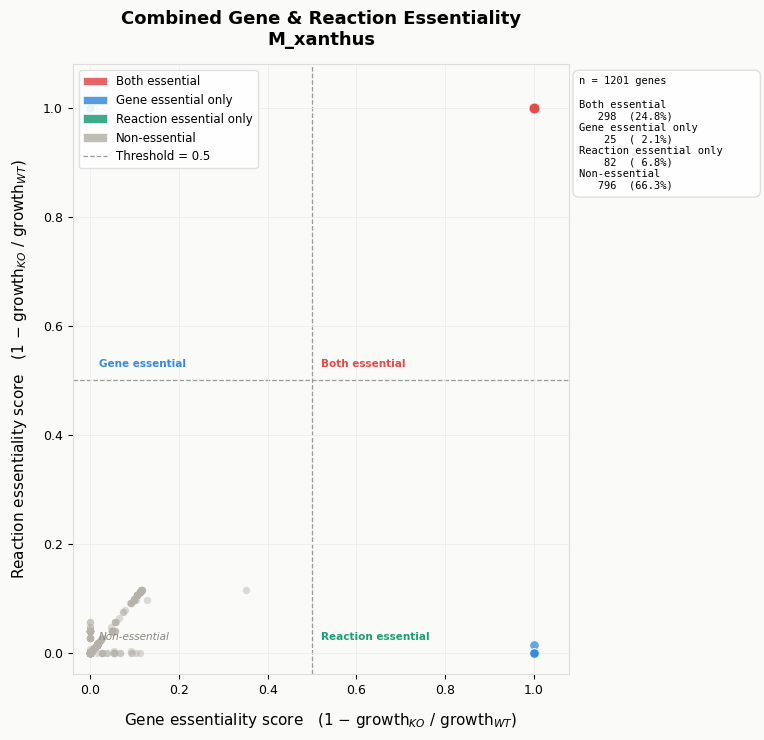

In [12]:
"""
Combined Reaction & Gene Essentiality Plot for Genome-Scale Metabolic Models
=============================================================================
Uses COBRApy to perform single-gene and single-reaction deletion simulations,
then produces a combined scatter plot coloured by essentiality category.

Requirements:
    pip install cobra matplotlib seaborn numpy pandas

Usage:
    python gem_essentiality_plot.py                        # built-in E. coli core demo
    python gem_essentiality_plot.py my_model.xml           # any SBML / JSON / MAT model
    python gem_essentiality_plot.py my_model.json --threshold 0.1 --output fig.png
"""

import sys
import argparse
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import cobra
from cobra.flux_analysis import single_gene_deletion, single_reaction_deletion
from cobra.io import read_sbml_model, write_sbml_model

warnings.filterwarnings("ignore")


# ── colour palette ────────────────────────────────────────────────────────────
PALETTE = {
    "both":      "#E24B4A",   # both essential  → red
    "gene_only": "#378ADD",   # gene essential only → blue
    "rxn_only":  "#1D9E75",   # reaction essential only → green
    "none":      "#B4B2A9",   # non-essential → grey
}
ALPHA  = {"both": 0.85, "gene_only": 0.75, "rxn_only": 0.75, "none": 0.45}
SIZE   = {"both": 60,   "gene_only": 45,   "rxn_only": 45,   "none": 28 }
LABEL  = {
    "both":      "Both essential",
    "gene_only": "Gene essential only",
    "rxn_only":  "Reaction essential only",
    "none":      "Non-essential",
}


# ── I/O ───────────────────────────────────────────────────────────────────────
def load_model(path: str):
    ext = path.rsplit(".", 1)[-1].lower()
    if ext == "json":
        return cobra.io.load_json_model(path)
    if ext in ("mat", "m"):
        return cobra.io.load_matlab_model(path)
    return cobra.io.read_sbml_model(path)


# ── core calculations ─────────────────────────────────────────────────────────
def essentiality_score(deletion_df: pd.DataFrame,
                        wt_growth: float,
                        col: str = "growth") -> pd.Series:
    """Growth-reduction fraction: 0 = no effect, 1 = lethal."""
    if wt_growth < 1e-9:
        raise ValueError(
            "Wild-type growth is ~zero. Check objective / medium."
        )
    return (1.0 - deletion_df[col].clip(lower=0) / wt_growth).clip(0.0, 1.0)


def run_deletions(model, processes: int = 1):
    print("  Computing wild-type growth …", flush=True)
    wt_sol = model.optimize()
    if wt_sol.status != "optimal":
        raise RuntimeError(f"Model optimisation failed: {wt_sol.status}")
    wt_growth = wt_sol.objective_value
    print(f"  Wild-type growth rate : {wt_growth:.6f}", flush=True)

    # gene deletions
    print(f"  Running {len(model.genes)} single-gene deletions …", flush=True)
    gd = single_gene_deletion(model, processes=processes).reset_index()
    gd["ids"] = gd["ids"].apply(
        lambda x: next(iter(x)) if isinstance(x, (set, frozenset)) else x
    )
    gd = gd.rename(columns={"ids": "gene_id"})
    gd["gene_score"] = essentiality_score(gd, wt_growth)

    def gene_subsys(gid):
        rxns = list(model.genes.get_by_id(gid).reactions)
        return rxns[0].subsystem or "Unknown" if rxns else "Unknown"

    gd["subsystem"] = gd["gene_id"].apply(gene_subsys)

    # reaction deletions
    print(f"  Running {len(model.reactions)} single-reaction deletions …",
          flush=True)
    rd = single_reaction_deletion(model, processes=processes).reset_index()
    rd["ids"] = rd["ids"].apply(
        lambda x: next(iter(x)) if isinstance(x, (set, frozenset)) else x
    )
    rd = rd.rename(columns={"ids": "rxn_id"})
    rd["rxn_score"] = essentiality_score(rd, wt_growth)

    return gd, rd, wt_growth


def merge_essentiality(gene_df, rxn_df, model):
    """
    Per gene: take the MAX reaction essentiality across all reactions it
    catalyses (conservative — gene is reaction-essential if any of its
    reactions are essential).
    """
    rxn_score_map = rxn_df.set_index("rxn_id")["rxn_score"].to_dict()

    records = []
    for gene in model.genes:
        scores = [rxn_score_map.get(r.id, 0.0) for r in gene.reactions]
        max_rxn = max(scores) if scores else 0.0
        best_sub = ""
        if scores:
            best_idx = int(np.argmax(scores))
            best_sub = list(gene.reactions)[best_idx].subsystem or "Unknown"
        records.append({"gene_id": gene.id, "rxn_score_max": max_rxn,
                         "rxn_subsystem": best_sub})

    rxn_agg = pd.DataFrame(records)
    merged = gene_df.merge(rxn_agg, on="gene_id", how="left")
    merged["rxn_score"] = merged["rxn_score_max"].fillna(0.0)
    merged["subsystem"] = merged["subsystem"].replace("", "Unknown")
    return merged


def assign_category(df, threshold=0.5):
    ge = df["gene_score"] >= threshold
    re = df["rxn_score"]  >= threshold
    df = df.copy()
    df["category"] = np.select(
        [ge & re, ge & ~re, ~ge & re],
        ["both", "gene_only", "rxn_only"],
        default="none"
    )
    return df


# ── plotting ──────────────────────────────────────────────────────────────────
def plot_combined(df, model_name, threshold, output_path):
    fig, ax = plt.subplots(figsize=(9.5, 7.5))
    fig.patch.set_facecolor("#FAFAF8")
    ax.set_facecolor("#FAFAF8")

    # render non-essential first (background), essential groups on top
    for cat in ["none", "rxn_only", "gene_only", "both"]:
        sub = df[df["category"] == cat]
        ax.scatter(
            sub["gene_score"], sub["rxn_score"],
            c=PALETTE[cat], alpha=ALPHA[cat], s=SIZE[cat],
            linewidths=0.5 if cat != "none" else 0,
            edgecolors="white",
            zorder=4 if cat == "both" else (3 if cat != "none" else 2),
            rasterized=len(sub) > 2000,
        )

    # threshold dashed lines
    ax.axvline(threshold, color="#9a9a9a", lw=0.9, ls="--", zorder=1)
    ax.axhline(threshold, color="#9a9a9a", lw=0.9, ls="--", zorder=1)

    # quadrant annotation labels
    pad = 0.02
    ax.text(pad, threshold + pad, "Gene essential",
            color=PALETTE["gene_only"], fontsize=7.5, fontweight="bold", va="bottom")
    ax.text(pad, pad, "Non-essential",
            color="#888780", fontsize=7.5, style="italic", va="bottom")
    ax.text(threshold + pad, threshold + pad, "Both essential",
            color=PALETTE["both"], fontsize=7.5, fontweight="bold", va="bottom")
    ax.text(threshold + pad, pad, "Reaction essential",
            color=PALETTE["rxn_only"], fontsize=7.5, fontweight="bold", va="bottom")

    # axes cosmetics
    ax.set_xlim(-0.04, 1.08)
    ax.set_ylim(-0.04, 1.08)
    ax.set_xlabel(
        "Gene essentiality score   (1 − growth$_{KO}$ / growth$_{WT}$)",
        fontsize=11, labelpad=10)
    ax.set_ylabel(
        "Reaction essentiality score   (1 − growth$_{KO}$ / growth$_{WT}$)",
        fontsize=11, labelpad=10)
    ax.set_title(
        f"Combined Gene & Reaction Essentiality\n{model_name}",
        fontsize=13, fontweight="bold", pad=14)
    ax.tick_params(axis="both", labelsize=9)
    for sp in ax.spines.values():
        sp.set_edgecolor("#dddddd")
    ax.grid(True, color="#eeeeee", linewidth=0.6, zorder=0)

    # legend (colour patches + threshold line)
    handles = [
        mpatches.Patch(facecolor=PALETTE[c], label=LABEL[c],
                       alpha=0.85, edgecolor="white", linewidth=0.5)
        for c in ["both", "gene_only", "rxn_only", "none"]
    ]
    handles.append(Line2D([0], [0], color="#9a9a9a", lw=0.9, ls="--",
                          label=f"Threshold = {threshold}"))
    ax.legend(handles=handles, fontsize=8.5, framealpha=0.9,
              edgecolor="#dddddd", loc="upper left")

    # stats text box (right margin)
    counts = df["category"].value_counts()
    total  = len(df)
    stats = (
        f"n = {total} genes\n\n"
        + "\n".join(
            f"{LABEL[c]:<28}\n  {counts.get(c,0):>4}  "
            f"({counts.get(c,0)/total*100:4.1f}%)"
            for c in ["both","gene_only","rxn_only","none"]
        )
    )
    ax.text(1.02, 0.98, stats, transform=ax.transAxes,
            fontsize=7.5, va="top", ha="left", family="monospace",
            bbox=dict(boxstyle="round,pad=0.6", facecolor="white",
                      edgecolor="#dddddd", alpha=0.95))

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.savefig(output_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"  Figure saved → {output_path}")
    plt.show()


# ── CLI ───────────────────────────────────────────────────────────────────────
# def parse_args():
#     p = argparse.ArgumentParser(
#         description="Combined gene & reaction essentiality scatter plot."
#     )
#     p.add_argument("model", nargs="?", default=None,
#                    help="Model file (.xml / .json / .mat).  "
#                         "Omit to use the built-in E. coli core model.")
#     p.add_argument("--threshold", type=float, default=0.5,
#                    help="Essentiality cut-off (default: 0.5)")
#     p.add_argument("--output", default="essentiality_combined.png",
#                    help="Output figure filename (default: essentiality_combined.png)")
#     p.add_argument("--processes", type=int, default=1,
#                    help="Parallel workers for deletions (default: 1)")
    
#     return p.parse_args()
def parse_args():
    p = argparse.ArgumentParser(
        description="Combined gene & reaction essentiality scatter plot."
    )
    p.add_argument("model", nargs="?", default=None)
    p.add_argument("--threshold", type=float, default=0.5)
    p.add_argument("--output", default="essentiality_combined.png")
    p.add_argument("--processes", type=int, default=1)

    args, unknown = p.parse_known_args()  # <-- KEY CHANGE
    return args


def main():
    args = parse_args()

    # load
    if args.model is None:
        print("No model supplied — loading built-in E. coli core (textbook) …")
        from cobra.io import load_model
        model = read_sbml_model("/home/mickael/github/M_xanthus-E_coli-Predation/M_xanthus_model_V5.xml")
        model_name = "M_xanthus"
    # if args.model is None:
    #     print("No model supplied — loading built-in E. coli core (textbook) …")
    #     model = cobra.test.create_test_model("textbook")
    #     model_name = "E. coli core (textbook)"
    else:
        print(f"Loading: {args.model}")
        model = load_model(args.model)
        model_name = args.model.rsplit("/", 1)[-1].rsplit(".", 1)[0]

    print(f"  Genes: {len(model.genes)}  |  "
          f"Reactions: {len(model.reactions)}  |  "
          f"Metabolites: {len(model.metabolites)}")

    # compute
    gene_df, rxn_df, wt_growth = run_deletions(model, args.processes)

    # merge & classify
    print("  Merging scores …")
    merged = merge_essentiality(gene_df, rxn_df, model)
    merged = assign_category(merged, threshold=args.threshold)

    # save table
    csv_path = args.output.rsplit(".", 1)[0] + "_data.csv"
    merged.to_csv(csv_path, index=False)
    print(f"  Data  saved → {csv_path}")

    # summary
    counts = merged["category"].value_counts()
    total  = len(merged)
    print("\n── Essentiality summary ──────────────────────────────────")
    for cat, lbl in LABEL.items():
        n = counts.get(cat, 0)
        print(f"  {lbl:<30}  {n:>5}  ({n/total*100:5.1f} %)")
    print(f"  {'Total':<30}  {total:>5}")
    print()

    # plot
    plot_combined(merged, model_name, args.threshold, args.output)


if __name__ == "__main__":
    main()
